In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

In [46]:
df = pd.read_csv(r"C:\users\123\Desktop\Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [47]:
df.shape

(200, 5)

In [48]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [51]:
df.shape

(200, 4)

In [52]:
df = df.rename(columns={'TV Ad Budget ($)':'TV','Radio Ad Budget ($)':'radio','Newspaper Ad Budget ($)':'Newspaper','Sales ($)':'Sales'})
df.head()

,TV,radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


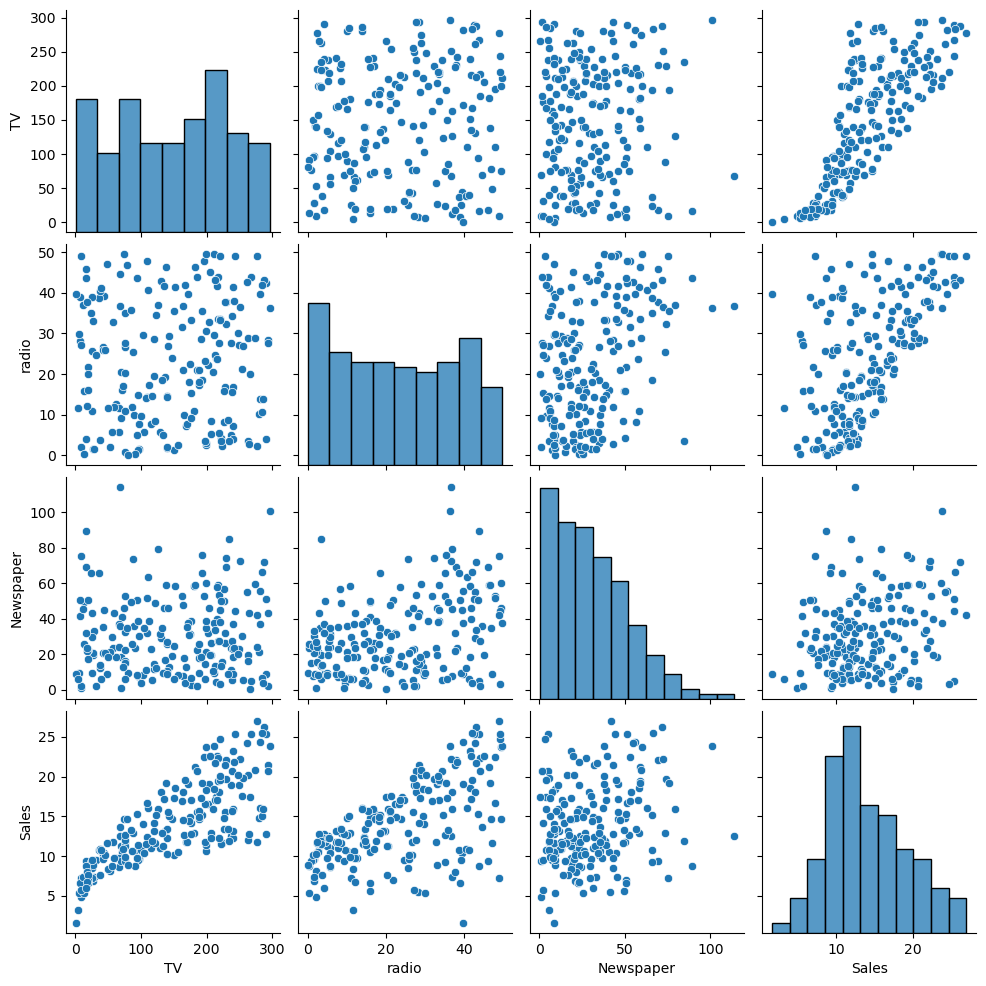

In [53]:
sns.pairplot(df)
plt.show()

<Axes: >

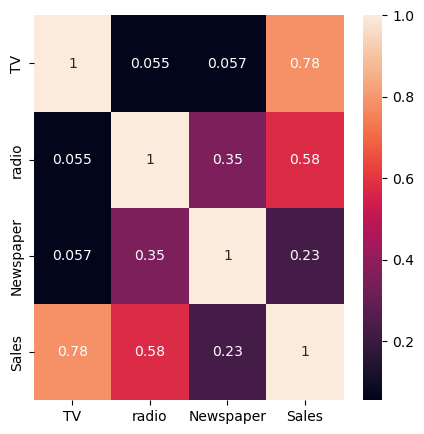

In [55]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(),annot=True)

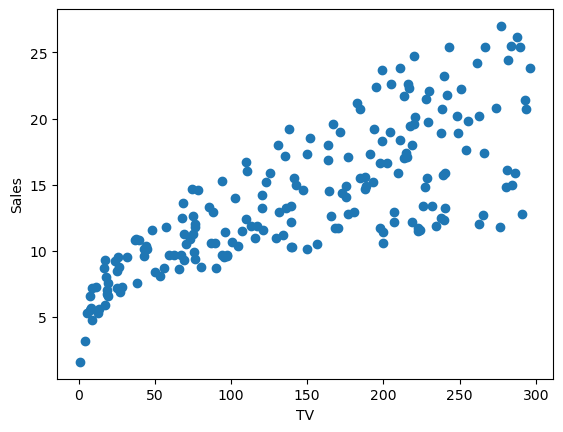

In [56]:
plt.scatter(df['TV'],df['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

In [57]:
x = df['TV']
y = df['Sales']

In [58]:
x.shape

(200,)

In [59]:
x = x.values.reshape(200, 1)

In [61]:
x.shape

(200, 1)

In [16]:
y.shape

(200,)

In [62]:
y=y.values.reshape(200,1)

In [63]:
y.shape

(200, 1)

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
lr=LinearRegression()

Simple Linear Regression

In [68]:
lr.fit(x_train,y_train)

LinearRegression()

In [24]:
y_pred=lr.predict(x_test)
y_pred

array([[14.71794394],
       [16.2115484 ],
       [20.74819743],
       [ 7.66403631],
       [17.37013877],
       [10.61402143],
       [17.2072847 ],
       [ 9.44612512],
       [17.46785121],
       [15.2669948 ],
       [ 8.58532504],
       [ 9.73460946],
       [18.03086098],
       [ 7.37089899],
       [13.61053628],
       [15.03899911],
       [ 7.45930549],
       [16.31391381],
       [10.62332738],
       [18.16579721],
       [17.79821232],
       [10.27435438],
       [ 8.88776831],
       [18.79394862],
       [10.33019006],
       [ 9.60897918],
       [17.05373658],
       [13.60123034],
       [11.17703121],
       [ 7.51048819],
       [16.41627922],
       [10.339496  ],
       [16.37440246],
       [ 7.90599093],
       [20.18053468],
       [18.203021  ],
       [ 9.36702457],
       [19.85482655],
       [12.57292322],
       [ 8.39920611]])

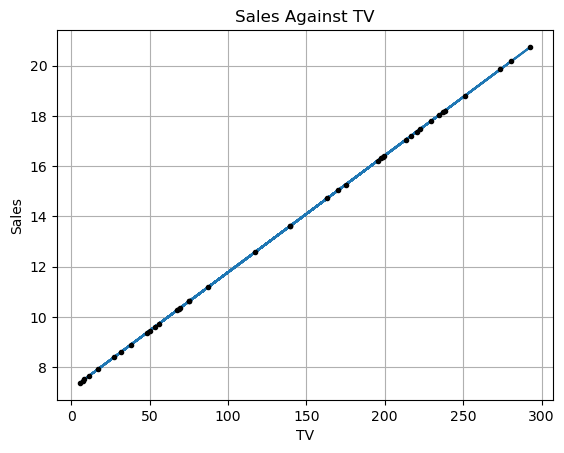

In [25]:
plt.figure()
plt.title('Sales Against TV')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.plot(x_test,y_pred)
plt.plot(x_test,y_pred,'k.')
plt.grid()
plt.show()

In [26]:
for i,predictions in enumerate(y_pred):
    print('actual Price: %s    and    Predicted Price: %s' %(y_test[i],predictions))

actual Price: [16.9]    and    Predicted Price: [14.71794394]
actual Price: [22.4]    and    Predicted Price: [16.2115484]
actual Price: [21.4]    and    Predicted Price: [20.74819743]
actual Price: [7.3]    and    Predicted Price: [7.66403631]
actual Price: [24.7]    and    Predicted Price: [17.37013877]
actual Price: [12.6]    and    Predicted Price: [10.61402143]
actual Price: [22.3]    and    Predicted Price: [17.2072847]
actual Price: [8.4]    and    Predicted Price: [9.44612512]
actual Price: [11.5]    and    Predicted Price: [17.46785121]
actual Price: [14.9]    and    Predicted Price: [15.2669948]
actual Price: [9.5]    and    Predicted Price: [8.58532504]
actual Price: [8.7]    and    Predicted Price: [9.73460946]
actual Price: [11.9]    and    Predicted Price: [18.03086098]
actual Price: [5.3]    and    Predicted Price: [7.37089899]
actual Price: [10.3]    and    Predicted Price: [13.61053628]
actual Price: [11.7]    and    Predicted Price: [15.03899911]
actual Price: [5.5]  

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# y_test = actuel values
# y_pred = model predictions

In [29]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [30]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.444420003751043
MSE : 10.204654118800956
RMSE : 3.194472431998898
R2 Score : 0.6766954295627076


Multi Linear Regression

In [83]:
x = df.drop('Sales',axis=1)
y = df['Sales']

In [84]:
x

,TV,radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [85]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [86]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [87]:
lr.fit(x_train,y_train)

LinearRegression()

In [88]:
y_pred = lr.predict(x_test)
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [89]:
for i,predictions in enumerate(y_pred):
    print('actual Price: %s   and   Predicted Price: %s' %(y_test.iloc[i],predictions))

actual Price: 16.9   and   Predicted Price: 16.408024203228628
actual Price: 22.4   and   Predicted Price: 20.88988208714789
actual Price: 21.4   and   Predicted Price: 21.553843179089554
actual Price: 7.3   and   Predicted Price: 10.60850256198491
actual Price: 24.7   and   Predicted Price: 22.11237325985767
actual Price: 12.6   and   Predicted Price: 13.105591724016461
actual Price: 22.3   and   Predicted Price: 21.05719191631465
actual Price: 8.4   and   Predicted Price: 7.461010344558372
actual Price: 11.5   and   Predicted Price: 13.606345805433925
actual Price: 14.9   and   Predicted Price: 15.155069668921396
actual Price: 9.5   and   Predicted Price: 9.048319924103872
actual Price: 8.7   and   Predicted Price: 6.653283124939039
actual Price: 11.9   and   Predicted Price: 14.345544865081418
actual Price: 5.3   and   Predicted Price: 8.903493328870415
actual Price: 10.3   and   Predicted Price: 9.689590280381111
actual Price: 11.7   and   Predicted Price: 12.164943859142404
actual

In [90]:
# y_test = actual values
# y_pred = model predictions

In [91]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [92]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.4607567168117601
MSE : 3.1740973539761073
RMSE : 1.781599661533451
R2 Score : 0.8994380241009119


Polynomial Regression

In [93]:
poly_feature = PolynomialFeatures(degree=2)

In [94]:
x_train = poly_feature.fit_transform(x_train)
x_test = poly_feature.fit_transform(x_test)

In [95]:
pr=LinearRegression()

In [96]:
pr.fit(x_train,y_train)

LinearRegression()

In [97]:
y_pred = pr.predict(x_test)
y_pred

array([17.25443578, 22.7193321 , 20.42799436,  7.542709  , 24.37103037,
       12.55927164, 22.80784986,  8.34371358, 12.0586023 , 15.69024565,
        7.89166367,  8.27082715, 11.86055971,  6.16591094, 10.57664393,
       12.3628954 ,  6.74390963, 16.65082111, 10.68661722, 19.03888161,
       20.15223945, 13.1137814 ,  9.56273868, 22.10675225,  8.96725241,
        7.7794437 , 22.40745151, 12.72065973, 10.25529986,  6.22368636,
       11.64677688, 10.22431946, 23.39763949,  9.17403232, 15.36143449,
       21.05675814, 10.9795286 , 20.23370753, 11.85153256,  6.58779915])

In [100]:
for i,predictions in enumerate(y_pred):
    print('actual Price: %s   and   Predicted Price: %s' %(y_test.iloc[i],predictions))

actual Price: 16.9   and   Predicted Price: 17.25443578421151
actual Price: 22.4   and   Predicted Price: 22.719332098787994
actual Price: 21.4   and   Predicted Price: 20.427994359934466
actual Price: 7.3   and   Predicted Price: 7.542708996441467
actual Price: 24.7   and   Predicted Price: 24.371030368769837
actual Price: 12.6   and   Predicted Price: 12.55927163560403
actual Price: 22.3   and   Predicted Price: 22.80784986147419
actual Price: 8.4   and   Predicted Price: 8.343713576679052
actual Price: 11.5   and   Predicted Price: 12.05860230253352
actual Price: 14.9   and   Predicted Price: 15.690245648360358
actual Price: 9.5   and   Predicted Price: 7.891663667903806
actual Price: 8.7   and   Predicted Price: 8.270827153870068
actual Price: 11.9   and   Predicted Price: 11.860559712580265
actual Price: 5.3   and   Predicted Price: 6.1659109433789165
actual Price: 10.3   and   Predicted Price: 10.576643926736418
actual Price: 11.7   and   Predicted Price: 12.362895400851446
actua

In [102]:
# y_test = actual values
# y_pred = model predictions 

In [104]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [105]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.5261794444044042
MSE : 0.4129102285379275
RMSE : 0.6425809120553827
R2 Score : 0.9869181490609595
